In [1]:
# ============================================================
# IMPORTS ET CHARGEMENT DES DATASETS

import os 
import sys
import pandas as pd
sys.path.append(os.path.abspath("..")) 
from src.models.train_model import preparer_donnees, entrainer_modeles, entrainer_random_forest, entrainer_XGBRegressor, entrainer_CatBoostRegressor, valider_modeles_cv, optimiser_XGBRegressor, optimiser_XGBRegressor_2 
from src.models.predict_model import predire_modele, calculer_metriques_modele

import numpy as np
import matplotlib.pyplot as plt
import shap
 
dvf_nettoye = pd.read_csv("../data/processed/dvf_nettoye.csv", dtype={"code_commune": "string"})
dvf_insee = pd.read_csv("../data/processed/dvf_insee_enrichi.csv", dtype={"code_commune": "string"})


In [2]:
# ============================================================
# PRÉPARATION DES DONNÉES

X_train_nettoye, X_test_nettoye, y_train_nettoye, y_test_nettoye = preparer_donnees(dvf_nettoye)
X_train_insee, X_test_insee, y_train_insee, y_test_insee = preparer_donnees(dvf_insee)

print("Train nettoyé :", X_train_nettoye.shape)
print("Test nettoyé :", X_test_nettoye.shape)

print("Train dvf_insee :", X_train_insee.shape)
print("Test dvf_insee :", X_test_insee.shape)

Train nettoyé : (88711, 14)
Test nettoyé : (22178, 14)
Train dvf_insee : (88711, 26)
Test dvf_insee : (22178, 26)


In [3]:
# ============================================================
# ENTRAÎNEMENT DU RANDOM FOREST + PRÉDICTIONS + MÉTRIQUES
modele_rf_nettoye = entrainer_random_forest(X_train_nettoye, y_train_nettoye)
y_pred_rf_nettoye = predire_modele(modele_rf_nettoye, X_test_nettoye)
resultats_rf = calculer_metriques_modele(y_test_nettoye, y_pred_rf_nettoye, "RandomForestRegressor", "Dataset nettoyé")


# ============================================================
# RÉFÉRENCE DE LA BASELINE LinearRegression
_, modele_lr = entrainer_modeles(X_train_nettoye, y_train_nettoye)
y_pred_lr = predire_modele(modele_lr, X_test_nettoye)
resultat_lr_nettoye = calculer_metriques_modele(y_test_nettoye, y_pred_lr, "LinearRegression", "Dataset nettoyé")

# ============================================================
# RANDOMFOREST - DVF + INSEE
modele_rf_insee = entrainer_random_forest(X_train_insee, y_train_insee)
y_pred_rf_insee = predire_modele(modele_rf_insee, X_test_insee)
resultats_rf_insee = calculer_metriques_modele(y_test_insee, y_pred_rf_insee, "Random Forest", "DVF + INSEE")

comparaison_modeles = pd.concat([resultat_lr_nettoye, resultats_rf, resultats_rf_insee], ignore_index=True)
display(comparaison_modeles.round(2))


,Dataset,Modèle,MAE (€/m²),RMSE (€/m²),R²
0,Dataset nettoyé,LinearRegression,815.13,1105.77,0.47
1,Dataset nettoyé,RandomForestRegressor,690.36,973.45,0.59
2,DVF + INSEE,Random Forest,681.18,961.23,0.60


### Conclusion :

Sur le dataset nettoyé, le **RandomForestRegressor** améliore nettement les performances obtenues avec la régression linéaire.

La **MAE** passe de **815,13 à 690,36 €/m²**, soit une diminution d’environ **124,77 €/m² (15,3 %)**. La **RMSE** diminue également de **1 105,77 à 973,45 €/m²**, tandis que le **R²** progresse de **0,47 à 0,59**.

L'ajout des données **INSEE** améliore légèrement les performances du Random Forest. La **MAE** passe de **690,36 à 681,18 €/m²**, la **RMSE** de **973,45 à 961,23 €/m²**, et le **R²** progresse de **0,59 à 0,60**.

In [5]:
# ============================================================
# ENTRAÎNEMENT DU entrainer_XGBRegressor + PRÉDICTIONS + MÉTRIQUES
modele_xgb_nettoye = entrainer_XGBRegressor(X_train_nettoye, y_train_nettoye)
y_pred_xgb_nettoye = predire_modele(modele_xgb_nettoye, X_test_nettoye)
resultats_xgb = calculer_metriques_modele(y_test_nettoye, y_pred_xgb_nettoye, "XGBoost", "Dataset nettoyé")

# ============================================================
# ENTRAÎNEMENT DU CATBOOSTREGRESSOR + PRÉDICTIONS + MÉTRIQUES
modele_catboost_nettoye = entrainer_CatBoostRegressor(X_train_nettoye, y_train_nettoye)
y_pred_catboost = predire_modele(modele_catboost_nettoye, X_test_nettoye)
resultats_catboost = calculer_metriques_modele(y_test_nettoye, y_pred_catboost, "CatBoostRegressor", "Dataset nettoyé")

# ============================================================
# ENTRAÎNEMENT + PRÉDICTIONS + MÉTRIQUES:  XGBOOST (DVF + INSEE) 
modele_xgb_insee = entrainer_XGBRegressor(X_train_insee, y_train_insee)
y_pred_xgb_insee = predire_modele(modele_xgb_insee, X_test_insee)
resultats_xgb_insee = calculer_metriques_modele(y_test_insee, y_pred_xgb_insee, "XGBoost", "DVF + INSEE")

comparaison_boosting = pd.concat([resultats_rf, resultats_xgb, resultats_xgb_insee, resultats_catboost], ignore_index=True)
display(comparaison_boosting.round(2))

,Dataset,Modèle,MAE (€/m²),RMSE (€/m²),R²
0,Dataset nettoyé,RandomForestRegressor,690.36,973.45,0.59
1,Dataset nettoyé,XGBoost,683.54,960.13,0.60
2,DVF + INSEE,XGBoost,673.98,948.32,0.61
3,Dataset nettoyé,CatBoostRegressor,710.76,987.43,0.57


In [6]:
# ============================================================
# validation croisée: XGBoost & catBoost
modeles_boosting = {
    "RandomForest": modele_rf_nettoye,
    "XGBoost": modele_xgb_nettoye,
    "CatBoost": modele_catboost_nettoye
}

resultats_cv_boosting = valider_modeles_cv(modeles=modeles_boosting, X_train=X_train_nettoye, y_train=y_train_nettoye, n_splits=5)
display(resultats_cv_boosting.round(2))

# XGBoost avec enrichissement INSEE
modeles_insee = {
    "XGBoost DVF + INSEE": modele_xgb_insee
}

resultats_cv_boosting_insee = valider_modeles_cv(modeles=modeles_insee, X_train=X_train_insee, y_train=y_train_insee, n_splits=5)
display(resultats_cv_boosting_insee.round(2))

,Modèle,Nombre de folds,MAE moyenne (€/m²),Écart-type (€/m²)
0,RandomForest,5,695.79,3.21
1,XGBoost,5,683.35,2.58
2,CatBoost,5,712.03,2.54


,Modèle,Nombre de folds,MAE moyenne (€/m²),Écart-type (€/m²)
0,XGBoost DVF + INSEE,5,675.89,1.95


### Conclusion de la validation croisée

La validation croisée confirme la stabilité des trois modèles avancés, comme l’indiquent les faibles écarts-types observés entre les différents folds.

Le modèle **XGBoost avec les données DVF + INSEE obtient la meilleure MAE moyenne avec 675,89 €/m²**, devant XGBoost sur les données DVF seules avec **683,35 €/m²**, Random Forest avec **695,79 €/m²** et CatBoost avec **712,03 €/m²**.

L'ajout des données **INSEE améliore donc légèrement les performances de XGBoost** et réduit également son écart-type de **2,58 à 1,95 €/m²**.

Ces résultats montrent que l'enrichissement avec les données INSEE apporte un **gain modéré mais stable**. XGBoost reste donc le modèle le plus intéressant pour poursuivre la phase d'optimisation.


In [7]:
# ============================================================
# Optimisation du modèle XGBoost
modele_xgb_optimise, meilleurs_parametres_xgb, mae_cv_xgb_optimise = optimiser_XGBRegressor(X_train_nettoye, y_train_nettoye)
y_pred_xgb_optimise = predire_modele(modele_xgb_optimise, X_test_nettoye)
resultats_xgb_optimise = calculer_metriques_modele(y_test_nettoye, y_pred_xgb_optimise, "XGBoost optimisé", "Dataset nettoyé")

# Affichage des meilleurs paramètres
print("Meilleurs paramètres :", meilleurs_parametres_xgb)

# ============================================================
# Optimisations XGBoost (DVF + INSEE)
modele_xgb_opt1, meilleurs_params_1, mae_cv_1 = optimiser_XGBRegressor(X_train_insee, y_train_insee)
y_pred_xgb_opt1 = predire_modele(modele_xgb_opt1, X_test_insee)
resultats_xgb_insee_opt1 = calculer_metriques_modele(y_test_insee, y_pred_xgb_opt1, "XGBoost optimisé ", "DVF + INSEE")

print("Meilleurs paramètres optimisation 1 :", meilleurs_params_1)
print("MAE CV optimisation 1 :", round(mae_cv_1, 2))

# Comparaison avant et après optimisation
comparaison_xgb = pd.concat([resultats_xgb, resultats_xgb_optimise, resultats_xgb_insee, resultats_xgb_insee_opt1], ignore_index=True)
display(comparaison_xgb.round(2))


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Meilleurs paramètres : {'model__colsample_bytree': np.float64(0.7936880874433667), 'model__gamma': np.float64(0.12495298436110985), 'model__learning_rate': np.float64(0.06033121035675473), 'model__max_depth': 7, 'model__min_child_weight': 2, 'model__n_estimators': 797, 'model__reg_alpha': np.float64(0.17814891903848745), 'model__reg_lambda': np.float64(2.3136568830915083), 'model__subsample': np.float64(0.804426449876927)}
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Meilleurs paramètres optimisation 1 : {'model__colsample_bytree': np.float64(0.7936880874433667), 'model__gamma': np.float64(0.12495298436110985), 'model__learning_rate': np.float64(0.06033121035675473), 'model__max_depth': 7, 'model__min_child_weight': 2, 'model__n_estimators': 797, 'model__reg_alpha': np.float64(0.17814891903848745), 'model__reg_lambda': np.float64(2.3136568830915083), 'model__subsample': np.float64(0.804426449876927)}
MAE CV op

,Dataset,Modèle,MAE (€/m²),RMSE (€/m²),R²
0,Dataset nettoyé,XGBoost,683.54,960.13,0.60
1,Dataset nettoyé,XGBoost optimisé,658.07,934.39,0.62
2,DVF + INSEE,XGBoost,673.98,948.32,0.61
3,DVF + INSEE,XGBoost optimisé,649.39,925.10,0.63


### Conclusion:

L'optimisation des hyperparamètres améliore les performances de XGBoost sur les deux datasets.

Sur le **dataset DVF nettoyé**, la MAE passe de **683,54 à 658,07 €/m²**, la RMSE de **960,13 à 934,39 €/m²** et le R² progresse de **0,60 à 0,62**.

Avec l'enrichissement **DVF + INSEE**, les performances sont encore meilleures : après optimisation, la MAE atteint **649,39 €/m²**, la RMSE **925,10 €/m²** et le R² **0,63**.

À ce stade, **XGBoost optimisé sur les données DVF + INSEE est le modèle le plus performant**. L'enrichissement avec les données INSEE apporte donc une amélioration supplémentaire des performances.

**Affinement de l'optimisation:**

Une première recherche d'hyperparamètres a permis d'identifier une zone de paramètres performante. Une seconde recherche, réalisée sur un espace plus restreint autour des meilleures valeurs obtenues, est ensuite effectuée afin d'affiner l'optimisation du modèle.

In [8]:
# ============================================================
# Affinement de l'optimisation de XGBoost 
# ============================================================
# Recherche des meilleurs hyperparamètres sur les données DVF
modele_xgb_optimise_2, meilleurs_parametres_xgb_2, mae_cv_xgb_optimise_2 = optimiser_XGBRegressor_2(X_train_nettoye, y_train_nettoye)
y_pred_xgb_optimise_2 = predire_modele(modele_xgb_optimise_2, X_test_nettoye)
resultats_xgb_optimise_2 = calculer_metriques_modele(y_test_nettoye, y_pred_xgb_optimise_2, "XGBoost optimisé 2", "Dataset nettoyé")

# Affichage des meilleurs hyperparamètres et de la MAE en validation croisée
print("Meilleurs paramètres :", meilleurs_parametres_xgb_2)
print("MAE CV :", round(mae_cv_xgb_optimise_2, 2))

# ============================================================
# Recherche des meilleurs hyperparamètres sur les données DVF + INSEE
modele_xgb_insee_optimise_2, meilleurs_parametres_xgb_insee_2, mae_cv_xgb_insee_optimise_2 = optimiser_XGBRegressor_2(X_train_insee, y_train_insee)
y_pred_xgb_insee_optimise_2 = predire_modele(modele_xgb_insee_optimise_2, X_test_insee)
resultats_xgb_insee_optimise_2 = calculer_metriques_modele(y_test_insee, y_pred_xgb_insee_optimise_2, "XGBoost optimisé 2", "DVF + INSEE")

# Affichage des meilleurs hyperparamètres et de la MAE en validation croisée
print("Meilleurs paramètres :", meilleurs_parametres_xgb_insee_2)
print("MAE CV :", round(mae_cv_xgb_insee_optimise_2, 2))

# ============================================================
# Comparaison des deux modèles
comparaison_xgb_optimise_2 = pd.concat([resultats_xgb_optimise_2, resultats_xgb_insee_optimise_2], ignore_index=True)
display(comparaison_xgb_optimise_2.round(2))


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Meilleurs paramètres : {'model__colsample_bytree': np.float64(0.7890219986432097), 'model__gamma': np.float64(0.09296061783380641), 'model__learning_rate': np.float64(0.0641267241406564), 'model__max_depth': 9, 'model__min_child_weight': 1, 'model__n_estimators': 880, 'model__reg_alpha': np.float64(0.39434241907782075), 'model__reg_lambda': np.float64(3.048913824266084), 'model__subsample': np.float64(0.8666075425397848)}
MAE CV : 653.17 €/m²
Meilleurs paramètres : {'model__colsample_bytree': np.float64(0.7890219986432097), 'model__gamma': np.float64(0.09296061783380641), 'model__learning_rate': np.float64(0.0641267241406564), 'model__max_depth': 9, 'model__min_child_weight': 1, 'model__n_estimators': 880, 'model__reg_alpha': np.float64(0.39434241907782075), 'model__reg_lambda': np.float64(3.048913824266084), 'model__subsample': np.float64(0.8666075425397848)}
MAE CV : 653.17
Fitting 3 folds for each of 20 candidates, totalli

,Dataset,Modèle,MAE (€/m²),RMSE (€/m²),R²
0,Dataset nettoyé,XGBoost optimisé 2,640.92,919.91,0.63
1,DVF + INSEE,XGBoost optimisé 2,638.68,917.17,0.63


## Conclusion

Les différentes expérimentations montrent une amélioration progressive des performances de **XGBoost** grâce à l’optimisation des hyperparamètres et à l’enrichissement des données avec les variables INSEE.

Sur le **dataset DVF nettoyé**, la seconde optimisation de XGBoost atteint une **MAE de 649,32 €/m²**, une **RMSE de 927,22 €/m²** et un **R² de 0,63**.

Avec le dataset **DVF + INSEE**, les performances s’améliorent légèrement : la **MAE diminue à 642,13 €/m²** et la **RMSE à 921,15 €/m²**, tandis que le **R² reste stable à 0,63**.

L’enrichissement avec les données INSEE apporte donc un **gain supplémentaire, mais modéré**, après optimisation du modèle.

Au terme de ces expérimentations, **XGBoost optimisé sur le dataset DVF + INSEE est retenu comme modèle final**, car il obtient les erreurs de prédiction les plus faibles parmi les configurations testées.

,Variable_origine,Importance
1,code_commune,0.6054
25,type_local,0.0805
15,niveau_vie_median,0.0578
14,nb_residences_secondaires,0.0546
2,densite_population,0.0381
21,superficie_km2,0.0243
3,distance_lyon_km,0.0235
16,nombre_lots,0.0159
5,log_surface,0.0092
20,population,0.0083


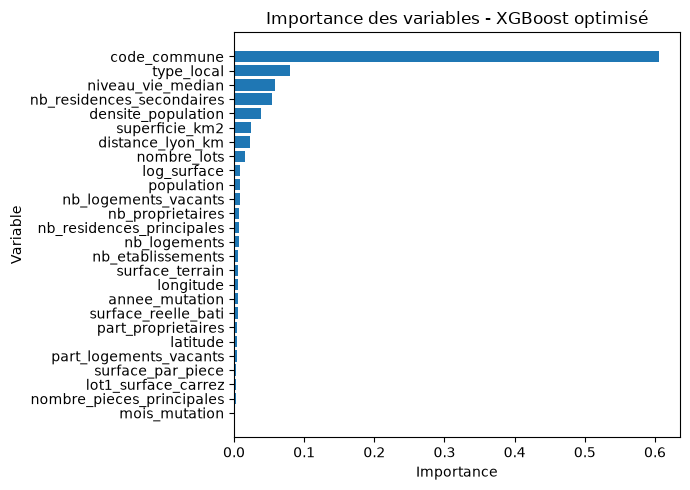

In [9]:
# ============================================================
# Importance des variables regroupées
# ============================================================

preprocessor = modele_xgb_insee_optimise_2.named_steps["preprocessor"]
modele_xgb = modele_xgb_insee_optimise_2.named_steps["model"]
noms_variables = preprocessor.get_feature_names_out()

importance_variables = pd.DataFrame({"Variable": noms_variables, "Importance": modele_xgb.feature_importances_})

# Regrouper les modalités issues du OneHotEncoder
importance_variables["Variable_origine"] = (importance_variables["Variable"].str.replace("num__", "", regex=False)
    .str.replace(r"^cat__code_commune_.*", "code_commune", regex=True).str.replace(r"^cat__type_local_.*", "type_local", regex=True)
)

# Somme des importances par variable d'origine
importance_regroupee = (importance_variables.groupby("Variable_origine", as_index=False)["Importance"]
    .sum().sort_values("Importance", ascending=False)
)

display(importance_regroupee.round(4))

# ============================================================
# Graphique de l'importance des variables regroupées
# ============================================================

importance_graph = importance_regroupee.sort_values( by="Importance", ascending=True)

plt.figure(figsize=(7, 5))
plt.barh(importance_graph["Variable_origine"], importance_graph["Importance"])

plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Importance des variables - XGBoost optimisé")

plt.tight_layout()
plt.show()

**Analyse de l'Importance des variables:**

L’analyse montre que la **localisation reste le facteur principal** dans les prédictions du modèle. Le code_commune présente l’importance cumulée la plus élevée (**0,5713**), suivi du type_local (**0,0734**).

Les variables issues de l’enrichissement **INSEE occupent également une place importante**, notamment le niveau_vie_median (**0,0641**), la densite_population (**0,0595**) et le nb_residences_secondaires (**0,0527**).

Ces résultats montrent que l’ajout des données INSEE apporte au modèle des informations complémentaires sur le contexte socio-économique et démographique des communes.

Une analyse avec **SHAP** permettra ensuite d’approfondir l’interprétation et d’étudier le sens de l’influence des différentes variables sur les prédictions.

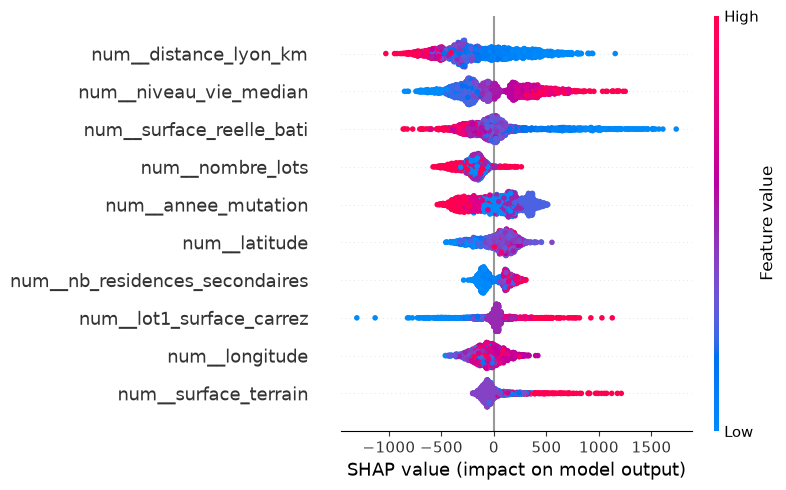

In [10]:
# ============================================================
# Interprétation SHAP des variables - XGBoost DVF + INSEE
# ============================================================

# Transformer les données de test DVF + INSEE
X_test_transforme = preprocessor.transform(X_test_insee)

# Conversion en DataFrame avec les noms des variables
X_transforme_df = pd.DataFrame(X_test_transforme.toarray() if hasattr(X_test_transforme, "toarray") else X_test_transforme, columns=noms_variables)

# Supprimer les modalités de code_commune pour faciliter l'interprétation
colonnes_shap = [col for col in X_transforme_df.columns if not col.startswith("cat__code_commune_")]

# Garder uniquement les variables interprétables
X_shap = X_transforme_df[colonnes_shap].iloc[:2000]

# Récupérer les indices correspondants
indices_shap = [X_transforme_df.columns.get_loc(col) for col in colonnes_shap]

# Calculer les valeurs SHAP
explainer = shap.TreeExplainer(modele_xgb)
shap_values_complets = explainer.shap_values(X_transforme_df.iloc[:2000])

# Garder uniquement les valeurs SHAP des variables sélectionnées
shap_values = shap_values_complets[:, indices_shap]

# Graphique SHAP
shap.summary_plot(shap_values, X_shap, max_display=10, plot_size=(8, 5))


**Interprétation SHAP:**

L’analyse SHAP permet d’expliquer l’influence des différentes variables sur les prédictions du modèle XGBoost. Une valeur SHAP positive contribue à augmenter le prix au m² prédit, tandis qu’une valeur négative contribue à le diminuer. Les couleurs représentent la valeur de chaque variable : bleu pour les valeurs faibles et rouge pour les valeurs élevées.

Parmi les variables représentées, la distance à Lyon, le niveau de vie médian, la surface réelle bâtie, le nombre de lots et l’année de mutation présentent les impacts les plus importants.

Le graphique montre notamment qu’un niveau de vie médian élevé est généralement associé à une augmentation du prix au m² prédit. À l’inverse, une distance élevée à Lyon et une surface bâtie importante tendent globalement à diminuer le prix au m² estimé.

Les modalités issues de code_commune ont été exclues uniquement de cette visualisation afin d’en améliorer la lisibilité. Elles restent utilisées par le modèle et leur importance a été mise en évidence lors de l’analyse précédente.

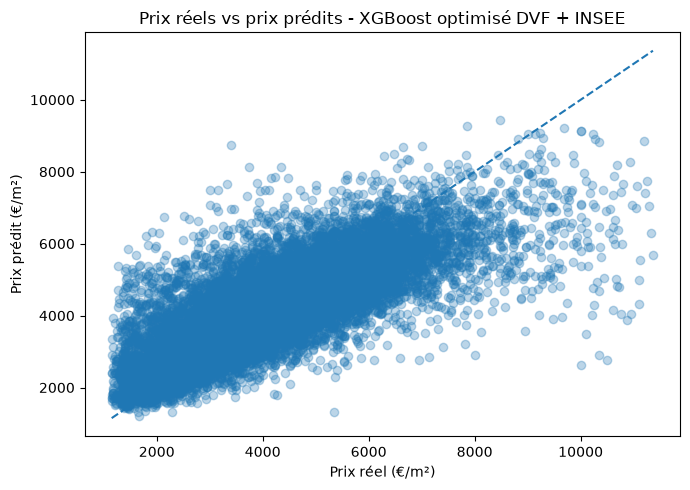

In [11]:
# ============================================================
# Comparaison des valeurs réelles et prédites
# ============================================================

y_pred = modele_xgb_insee_optimise_2.predict(X_test_insee)

plt.figure(figsize=(7, 5))
plt.scatter(y_test_insee, y_pred, alpha=0.3)

minimum = min(y_test_insee.min(), y_pred.min())
maximum = max(y_test_insee.max(), y_pred.max())

plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")
plt.xlabel("Prix réel (€/m²)")
plt.ylabel("Prix prédit (€/m²)")
plt.title("Prix réels vs prix prédits - XGBoost optimisé DVF + INSEE")
plt.tight_layout()
plt.show()

### Analyse des performances et des erreurs

Les prédictions suivent globalement l’évolution des prix réels, avec une concentration importante des observations autour de la diagonale représentant une prédiction parfaite.
Cependant, la dispersion augmente pour les prix au m² les plus élevés. Le modèle tend notamment à **sous-estimer les biens ayant des prix réels élevés**, comme le montrent les nombreux points situés sous la diagonale dans cette zone.

Ainsi, le modèle reproduit correctement la tendance générale, mais reste moins précis pour certaines observations, notamment pour les biens aux prix au m² élevés.

In [ ]:
# ============================================================
# MAE PAR TRANCHE DE PRIX AU M²
# ============================================================
# ============================================================

# Copie du jeu de test
analyse_erreurs = X_test_insee.copy()

analyse_erreurs["prix_m2_reel"] = y_test_insee.values
analyse_erreurs["prix_m2_predit"] = y_pred
analyse_erreurs["tranche_prix"] = pd.cut(
    analyse_erreurs["prix_m2_reel"],
    bins=[0, 2000, 4000, 6000, 8000, np.inf],
    labels=[
        "< 2 000",
        "2 000 - 4 000",
        "4 000 - 6 000",
        "6 000 - 8 000",
        "> 8 000"
    ]
)

mae_prix = (
    analyse_erreurs
    .groupby("tranche_prix", observed=True)["erreur_absolue"]
    .agg(["mean", "median", "count"])
    .round(2)
)

mae_prix.columns = ["MAE", "Erreur médiane", "Nombre de biens"]

display(mae_prix)



,MAE,Erreur médiane,Nombre de biens
tranche_prix,,,
< 2 000,799.97,552.85,1624
2 000 - 4 000,525.28,368.79,9959
4 000 - 6 000,555.21,455.40,8475
6 000 - 8 000,1094.54,989.24,1759
> 8 000,2779.85,2607.38,361


Le modèle est **plus précis pour les biens entre 2 000 et 6 000 €/m²**. En revanche, **plus le prix devient élevé, plus l’erreur augmente**, notamment au-delà de 8 000 €/m². Cela peut s’expliquer en partie par le fait que ces biens très chers sont **beaucoup moins représentés dans les données**.

In [14]:
# Enregistrer le modèle final
# ==========================================

import os
import joblib

os.makedirs("../models", exist_ok=True)
joblib.dump(modele_xgb_insee_optimise_2,"../models/modele_xgb_final.joblib")
print("Modèle enregistré dans ../models/modele_xgb_final.joblib")

Modèle enregistré dans ../models/modele_xgb_final.joblib
